In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [9]:
#Implement with MinMaxScaller
from scipy.spatial import distance
from sklearn import preprocessing
import pandas as pd
import numpy as np

scaler = preprocessing.MinMaxScaler()

df = pd.DataFrame({
    'x1': np.random.normal(0, 2, 10000),
    'x2': np.random.normal(5, 3, 10000),
    'x3': np.random.normal(-5, 5, 10000)
})

X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=['x1_scaled', 'x2_scaled', 'x3_scaled'])

print(df.head())
print(X_scaled.head())

         x1         x2         x3
0 -1.070365   5.991100  -5.755198
1 -0.125673   5.112855   2.485794
2  0.157530   3.589687 -11.595649
3  2.147692   2.554705  -7.768919
4  1.266704  12.603860  -0.738009
   x1_scaled  x2_scaled  x3_scaled
0   0.432818   0.594425   0.488211
1   0.497033   0.555278   0.709033
2   0.516284   0.487385   0.331713
3   0.651564   0.441252   0.434252
4   0.591679   0.889180   0.622649


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from tensorflow.keras.utils import to_categorical

In [12]:
df = pd.read_csv("./dataset/food_types.csv")
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Calories,61.0,72.540984,43.690416,10.0,25.0,80.0,100.0,200.0
Calories_Fat,61.0,9.344262,17.523209,0.0,0.0,0.0,10.0,90.0
Total_Fat,61.0,1.090164,1.954713,0.0,0.0,0.0,1.5,10.0
Sodium,61.0,53.360656,82.324163,0.0,0.0,20.0,70.0,330.0
Potassium,61.0,284.672131,120.584925,70.0,200.0,260.0,370.0,620.0
Total_Carbo,61.0,8.229508,9.085508,0.0,0.0,5.0,13.0,34.0


In [15]:
df.isnull().sum()

Calories        0
Calories_Fat    0
Total_Fat       0
Sodium          0
Potassium       0
Total_Carbo     0
Category        0
dtype: int64

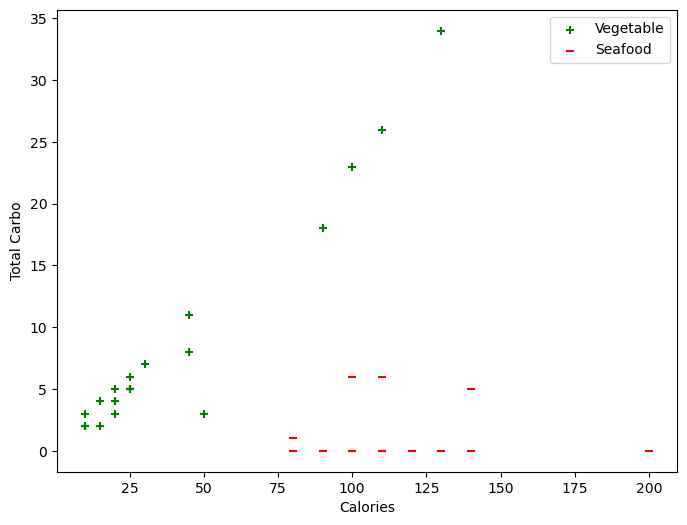

In [17]:
# Get Calories length and Calories_Fat data

x = df['Calories']
y = df['Total_Carbo']

# Get Calories length and Total_Carbo data of Vegetable

Vegetable_x = x[:22]
Vegetable_y = y[:22]

# Get Calories length and Calories_Fat data of Seafood

Seafood_x = x[42:62]
Seafood_y = y[42:62]

# Plot a scatter between Calories and Total Carbo content of Vegetable and Seafood

plt.figure(figsize=(8,6))
plt.scatter(Vegetable_x,Vegetable_y, marker='+', color='green', label = "Vegetable")
plt.scatter(Seafood_x,Seafood_y, marker='_', color='red', label = "Seafood")
plt.xlabel("Calories")
plt.ylabel("Total Carbo")
plt.legend()
plt.show()

In [21]:
# Prepare features X and target data Y
# Encode the target Y using with LabelEncoder
encoder = preprocessing.LabelEncoder()
encoder.fit(df["Category"])
Y = df.pop("Category")
Y = encoder.transform(Y)

X = df
print(X.shape)
print(Y[:10])

(61, 6)
[2 2 2 2 2 2 2 2 2 2]


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.30)

print(X.shape)
print(y.shape)


(61, 6)
(61,)


In [27]:
# Scale the feature X data using MinMaxScaler

#X_train = (X_train - X_train.min(0)) / X_train.ptp(0)
#X_test = (X_test - X_test.min(0)) / X_test.ptp(0)

scaler = preprocessing.MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

print(X_train.shape)
print(X_test.shape)

(42, 6)
(19, 6)


In [29]:
#import the KNeighborsClassifier class from sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

#Create KNeighborsClassifier with K = 7 and uniform weight
knn = KNeighborsClassifier(n_neighbors=7, weights='uniform')
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)
#print(knn.score(X_test,y_test))

print(metrics.accuracy_score(y_test, y_pred))

0.8947368421052632


In [99]:
#0 = Fruit, 1=Seafood, 2=Vegerable
from sklearn.linear_model import LogisticRegression

classes = {0: "Fruit", 1: "Seafood", 2: "Vegetable"}

#Making prediction on some unseen data 
#predict for the below observations

x_new = np.array([
        [10,0,0,0,140,2],
         [50,0,0,20,240,12],
         [200,90,10,55,430,0],
         [110,15,2,70,440,0]
        ])

model = LogisticRegression()
model.fit(X_train, y_train)

scaler = preprocessing.MinMaxScaler()

scaled_data = scaler.fit_transform(x_new)


y_predict= model.predict(scaled_data)

print(y_predict)
print(classes[y_predict[0]])
print(classes[y_predict[1]])
print(classes[y_predict[2]])
print(classes[y_predict[3]])

[2 0 1 1]
Vegetable
Fruit
Seafood
Seafood


In [101]:
#import metrics model to check the accuracy 
from sklearn import metrics
#Try running from k=1 through 25 and record testing accuracy
k_range = range(1,25)
scores_list = []
error_list = []
train_accuracy =np.empty(len(k_range))
test_accuracy = np.empty(len(k_range))
for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
        knn.fit(X_train,y_train)
        #y_pred=knn.predict(X_test)
        #scores[k] = metrics.accuracy_score(y_test,y_pred)
        #scores_list.append(metrics.accuracy_score(y_test,y_pred))
        #error_list.append(np.mean(y_pred != y_test))
        train_accuracy[k-1] = knn.score(X_train, y_train)
        test_accuracy[k-1] = knn.score(X_test, y_test)
        

Text(0, 0.5, 'Accuracy')

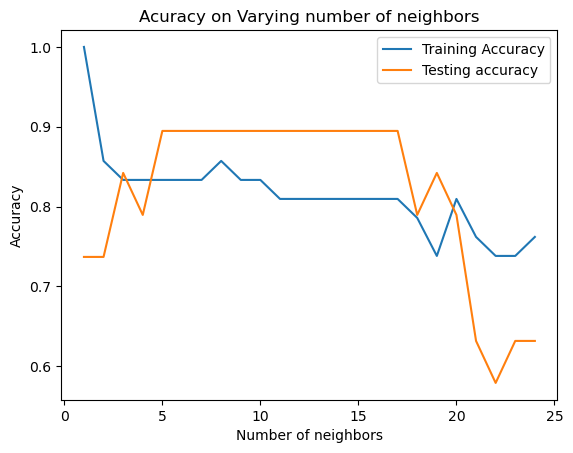

In [103]:
import matplotlib.pyplot as plt

plt.title('Acuracy on Varying number of neighbors')
plt.plot(k_range,train_accuracy, label='Training Accuracy')
plt.plot(k_range,test_accuracy, label='Testing accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')

Text(0, 0.5, 'Accuracy')

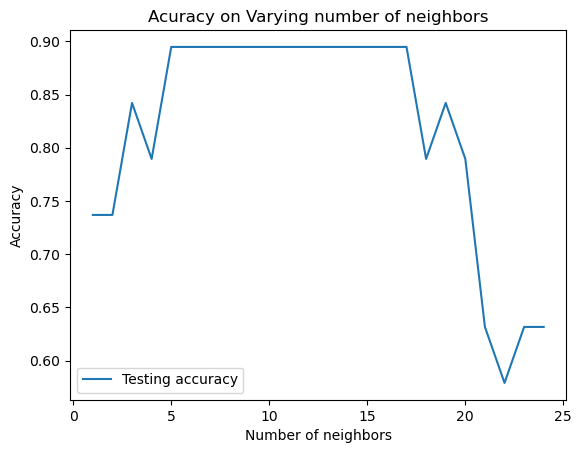

In [105]:
plt.title('Acuracy on Varying number of neighbors')
plt.plot(k_range,test_accuracy, label='Testing accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [111]:

df = pd.read_csv("./dataset/heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [113]:
X = df.drop(columns=["target"])  # Replace "target" with the actual name of your target column

y = df["target"]

scaler = preprocessing.StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=['age', 'sex', 'cp', 'trestbps', 'chol','fbs', 'restecg', 'thalach','exang','oldpeak','slope','ca','thal'])

X_train,X_test,y_train,y_test = train_test_split(X_scaled, y, test_size=0.35, random_state=42)

In [127]:

knn1 = KNeighborsClassifier(n_neighbors=k, weights='uniform')

knn1.fit(X_train,y_train)

y_pred= knn1.predict(X_test)


score = metrics.accuracy_score(y_test,y_pred)

print(score)

0.8189415041782729


In [129]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.73      0.80       180
           1       0.77      0.91      0.83       179

    accuracy                           0.82       359
   macro avg       0.83      0.82      0.82       359
weighted avg       0.83      0.82      0.82       359



In [131]:
#import metrics model to check the accuracy 
from sklearn import metrics
#Try running from k=1 through 25 and record testing accuracy
k_range = range(1,25)
scores_list = []
error_list = []
train_accuracy =np.empty(len(k_range))
test_accuracy = np.empty(len(k_range))
for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
        knn.fit(X_train,y_train)
        #y_pred=knn.predict(X_test)
        #scores[k] = metrics.accuracy_score(y_test,y_pred)
        #scores_list.append(metrics.accuracy_score(y_test,y_pred))
        #error_list.append(np.mean(y_pred != y_test))
        train_accuracy[k-1] = knn.score(X_train, y_train)
        test_accuracy[k-1] = knn.score(X_test, y_test)

Text(0, 0.5, 'Accuracy')

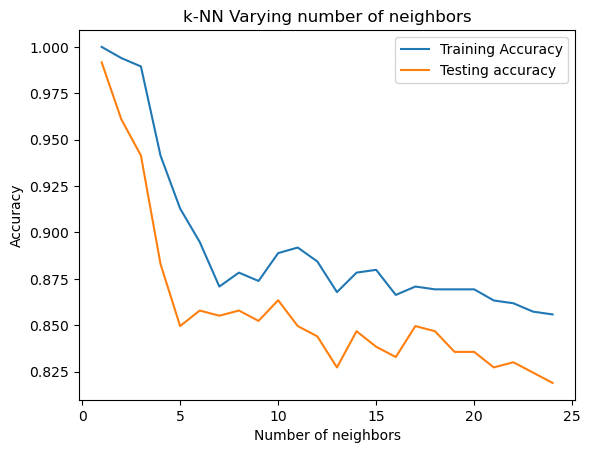

In [133]:
import matplotlib.pyplot as plt

plt.title('k-NN Varying number of neighbors')
plt.plot(k_range,train_accuracy, label='Training Accuracy')
plt.plot(k_range,test_accuracy, label='Testing accuracy')
plt.legend()
plt.xlabel('Number of neighbors')
plt.ylabel('Accuracy')